In [2]:
# grafica_rendimiento_postgresql.py
# Genera gráfica de mejora de rendimiento PostgreSQL antes/después de índices.

import os
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Ruta del CSV de resultados
csv_path = r"D:\Personal\MAESTRIA ASOFTWARE\Bases de datos\Actividad5\ecommify-db-mongo-optimizacion\postgresql\charts\postgresql_performance_results.csv"

# Carpeta de salida
output_dir = r"D:\Personal\MAESTRIA ASOFTWARE\Bases de datos\Actividad5\ecommify-db-mongo-optimizacion\postgresql\charts"
os.makedirs(output_dir, exist_ok=True)

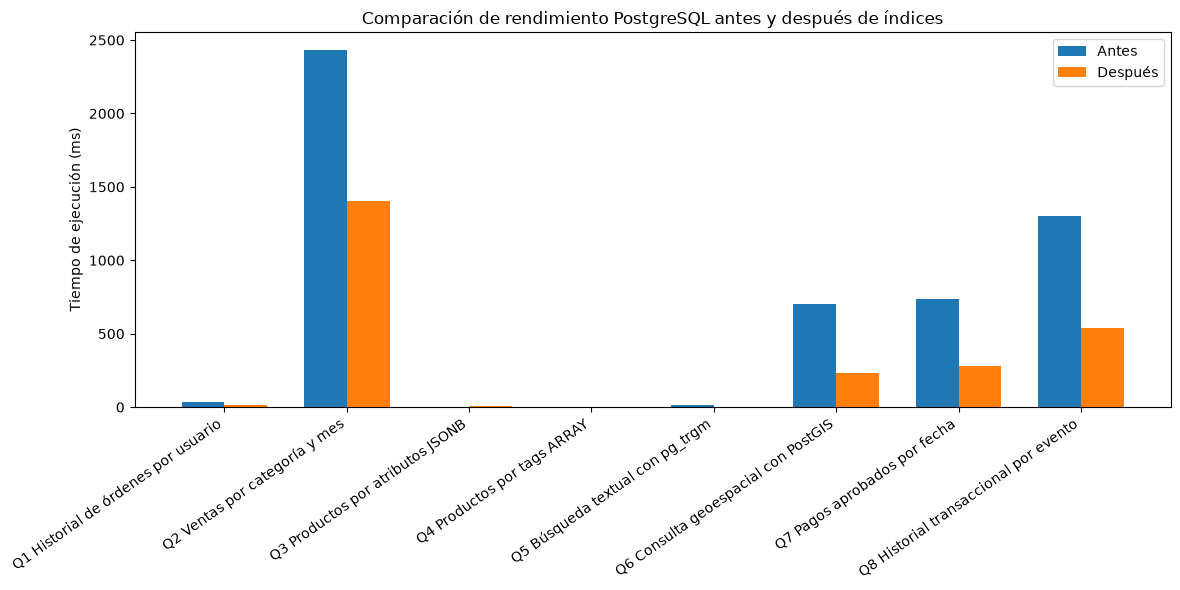

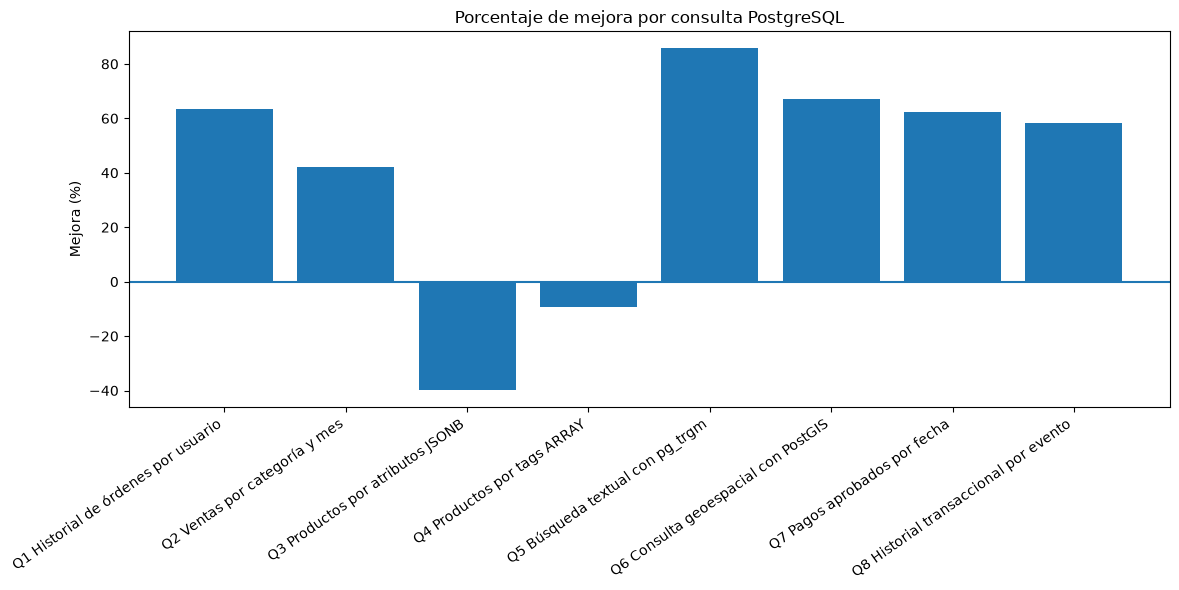

Archivos generados en: D:\Personal\MAESTRIA ASOFTWARE\Bases de datos\Actividad5\ecommify-db-mongo-optimizacion\postgresql\charts


In [5]:
# Leer resultados
df = pd.read_csv(csv_path)

# ==============================
# Gráfica 1: tiempos antes/después
# ==============================

plt.figure(figsize=(12, 6))

x = range(len(df))
width = 0.35

plt.bar(
    [i - width / 2 for i in x],
    df["execution_before_ms"],
    width,
    label="Antes"
)

plt.bar(
    [i + width / 2 for i in x],
    df["execution_after_ms"],
    width,
    label="Después"
)

plt.xticks(x, df["query"], rotation=35, ha="right")
plt.ylabel("Tiempo de ejecución (ms)")
plt.title("Comparación de rendimiento PostgreSQL antes y después de índices")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "postgresql_before_after_times.png"),
    dpi=150
)

plt.show()


# ==============================
# Gráfica 2: porcentaje de mejora
# ==============================

plt.figure(figsize=(12, 6))

plt.bar(
    df["query"],
    df["improvement_percent"]
)

plt.axhline(0)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mejora (%)")
plt.title("Porcentaje de mejora por consulta PostgreSQL")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "postgresql_improvement_percent.png"),
    dpi=150
)

plt.show()


# ==============================
# Exportar resumen Markdown
# ==============================

summary_path = os.path.join(output_dir, "postgresql_performance_summary.md")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# Resumen de rendimiento PostgreSQL\n\n")
    f.write("| Query | Antes (ms) | Después (ms) | Mejora (%) | Técnica |\n")
    f.write("|---|---:|---:|---:|---|\n")

    for _, row in df.iterrows():
        f.write(
            f"| {row['query']} | "
            f"{row['execution_before_ms']} | "
            f"{row['execution_after_ms']} | "
            f"{row['improvement_percent']} | "
            f"{row['index_type_used']} |\n"
        )

print("Archivos generados en:", output_dir)